In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
X,y = make_blobs(n_samples=1000,n_features=2,centers=5)

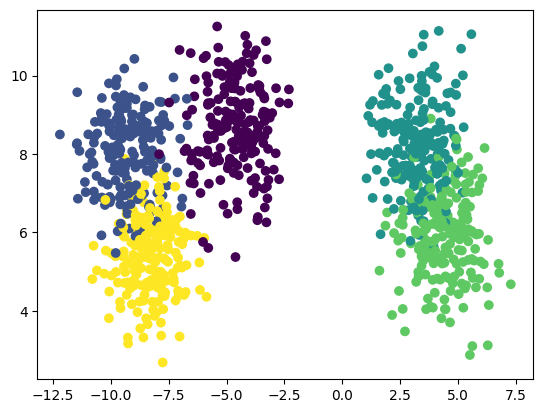

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
from sklearn.model_selection import train_test_split


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [7]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
from sklearn.cluster import KMeans

In [9]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

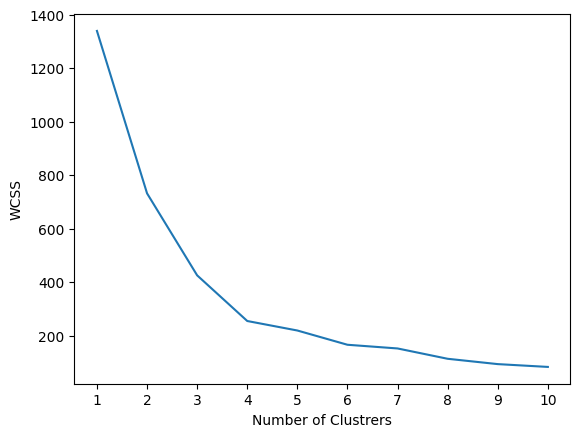

In [10]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans=KMeans(n_clusters=4,init="k-means++")

In [14]:
kmeans.fit(X_train_scaled)
y_pred=kmeans.predict(X_test_scaled)

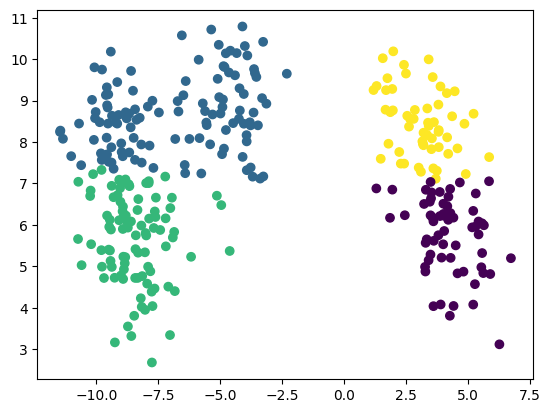

In [15]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [16]:
!pip install kneed


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
kl.elbow

np.int64(4)

In [19]:
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

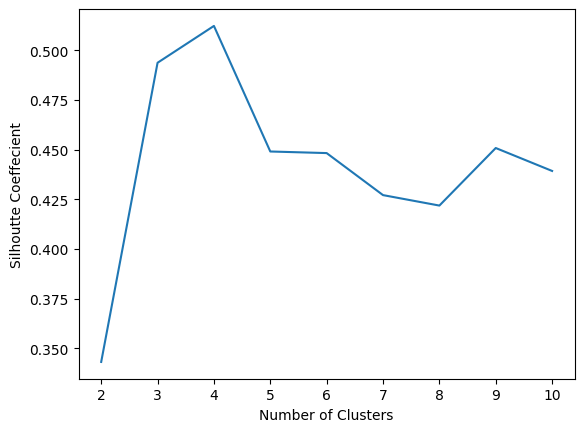

In [21]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()

In [23]:
from sklearn import cluster, datasets, mixture 
n_samples = 500
seed = 30
data = {
    "circles": datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed
),
     "moons":datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed),
     "blobs": datasets.make_blobs(n_samples=n_samples, random_state=seed)
    
}

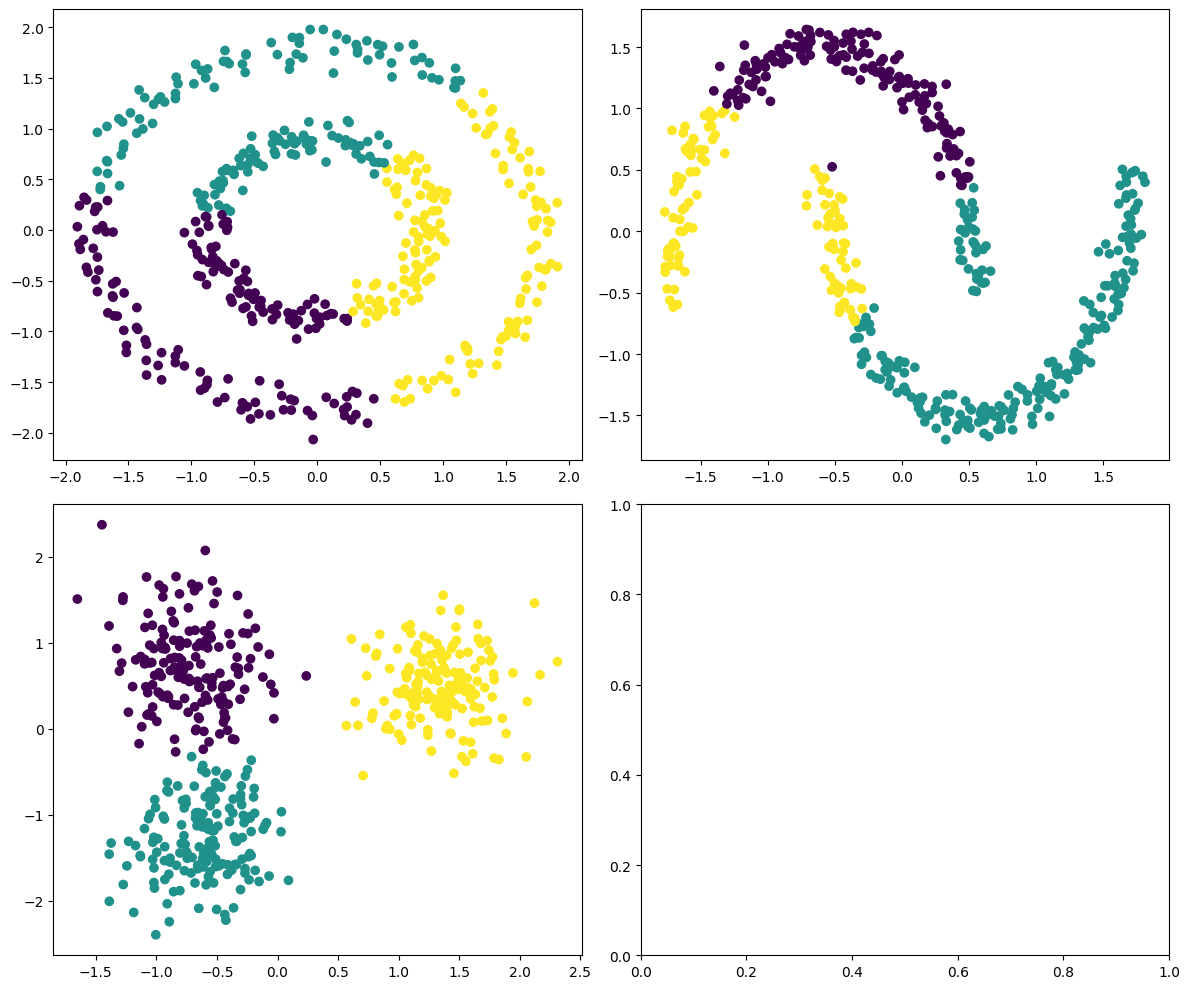

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create subplots - ONE plot with multiple panels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid
axes = axes.ravel()  # Flatten for easy indexing

i = 0
for name, (X, y_true) in data.items():
    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X_scaled)
    
    # Plot on subplot
    axes[i].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='viridis')

    i += 1

plt.tight_layout()
plt.show()
